In [32]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D


In [33]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return dos_normalized #3*unit_cell_atoms*broadened_dos_normalized

In [39]:
results_directory=dict()
for H2O_mol in [45, 90, 180,360,720, 1440]:
    for temperature in [100,200,300]:
        results_directory["../results/gromacs/pore/4nm/H2O/results/%d/md_prod_%d/" % (H2O_mol, temperature)]=(H2O_mol,temperature)


df_list=list()

min_energy=0
max_energy=1500

for data_directory,(H2O_mol,temperature) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        h5file.close()
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Weight"]=" ".join(filename.split("_")[:-1]).replace('b ','').capitalize()
        df_tmp["Method"]="MD"
        df_tmp["H2O Molecules"]=H2O_mol
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
        for species in ["Si","O"]:
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species)
            df_tmp[species]/=df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
                
        df_tmp["Temperature (K)"]=temperature
        df_tmp["Software"]=directory_split[2]
        df_tmp["Force Field"]="PoreMS"
        
        df_list.append(df_tmp)
        
df_dos_gromacs=pd.concat(df_list,ignore_index=True)

../results/gromacs/pore/4nm/H2O/results/45/md_prod_100/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/45/md_prod_200/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/45/md_prod_300/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/90/md_prod_100/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/90/md_prod_200/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/90/md_prod_300/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/180/md_prod_100/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/180/md_prod_200/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/180/md_prod_300/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/360/md_prod_100/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/360/md_prod_200/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/360/md_prod_300/b_incoherent_dos.h5
../results/gromacs/pore/4nm/H2O/results/720/md_prod_100/b_incoherent_dos.h5
../results/gromacs

In [40]:
df_dos_gromacs

,dos H (nm2/ps),dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Weight,Method,H2O Molecules,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,Temperature (K),Software,Force Field
0,0.000038,3.352107e-06,2.377017e-06,0.000035,0.125676,2.486911,9.999875e-01,Incoherent,MD,45,0.082720,0.000320,0.006192,0.005834,0.003192,100,gromacs,PoreMS
1,0.000040,3.586364e-06,2.547061e-06,0.000037,0.251353,2.428684,9.999500e-01,Incoherent,MD,45,0.165440,0.000333,0.006635,0.006242,0.003325,100,gromacs,PoreMS
2,0.000042,3.980012e-06,2.832438e-06,0.000039,0.377029,2.334653,9.998875e-01,Incoherent,MD,45,0.248160,0.000355,0.007378,0.006927,0.003545,100,gromacs,PoreMS
3,0.000046,4.537828e-06,3.236057e-06,0.000043,0.502705,2.209094,9.998000e-01,Incoherent,MD,45,0.330881,0.000386,0.008430,0.007898,0.003854,100,gromacs,PoreMS
4,0.000051,5.266408e-06,3.761891e-06,0.000047,0.628381,2.057531,9.996875e-01,Incoherent,MD,45,0.413601,0.000426,0.009800,0.009166,0.004251,100,gromacs,PoreMS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89977,0.000015,1.829002e-08,5.372536e-08,0.000015,627.753002,0.000000,1.120606e-18,Incoherent,MD,1440,413.187026,0.000031,0.000056,0.000017,0.001740,300,gromacs,PoreMS
89978,0.000015,1.830134e-08,5.374707e-08,0.000015,627.878678,0.000000,-1.803623e-17,Incoherent,MD,1440,413.269746,0.000031,0.000056,0.000017,0.001741,300,gromacs,PoreMS
89979,0.000015,1.830999e-08,5.376324e-08,0.000015,628.004354,0.000000,4.791684e-17,Incoherent,MD,1440,413.352466,0.000031,0.000056,0.000017,0.001741,300,gromacs,PoreMS
89980,0.000015,1.831583e-08,5.377394e-08,0.000015,628.130030,0.000000,9.315475e-18,Incoherent,MD,1440,413.435186,0.000031,0.000056,0.000017,0.001742,300,gromacs,PoreMS


In [36]:
results_directory=dict()

for H2O_mol in [45, 90, 180, 360, 720]:
    results_directory["../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/%d/mdanse"%H2O_mol]=H2O_mol

df_list=list()

min_energy=0
max_energy=1500

for data_directory,H2O_mol in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        h5file.close()
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Temperature (K)"]=int(filename.split("_")[2].replace('K',''))
        df_tmp["Weight"]=" ".join(filename.split("_")[:-2]).replace('b ','').capitalize()
        label="%s lammps"%(system.replace("_"," ").replace("nanoparticle", "np"))
        df_tmp["Method"]="MD"
        df_tmp["H2O Molecules"]=H2O_mol
        df_tmp["Force Field"]="ReaxFF2023"
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp,unit_cell_atoms=9)
        for species,unit_cell_atoms in {"Si":3,"O":6}.items():
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species,unit_cell_atoms)
            df_tmp[species]=df_tmp[species]/df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
        df_tmp["Software"]=directory_split[2]
        
        df_list.append(df_tmp)
df_dos_lammps=pd.concat(df_list,ignore_index=True)



../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/45/mdanse\b_incoherent_100K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/45/mdanse\b_incoherent_200K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/45/mdanse\b_incoherent_300K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/90/mdanse\b_incoherent_100K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/90/mdanse\b_incoherent_200K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/90/mdanse\b_incoherent_300K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/180/mdanse\b_incoherent_100K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/180/mdanse\b_incoherent_200K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/180/mdanse\b_incoherent_300K_dos.h5
../results/lammps/pore/beta_critobalite/reaxff2023/4nm/H2O/results/360/mdanse\b

In [41]:
df_dos_md=pd.concat([df_dos_lammps,df_dos_gromacs])
df_dos_md

,dos H (nm2/ps),dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,H2O Molecules,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Software
0,0.000012,4.386803e-06,2.318721e-06,0.000011,0.125676,2.486911,9.999875e-01,100,Incoherent,MD,45,ReaxFF2023,0.082720,0.000110,0.014790,0.014759,0.013943,1.000000,lammps
1,0.000012,4.580948e-06,2.443698e-06,0.000011,0.251353,2.428684,9.999500e-01,100,Incoherent,MD,45,ReaxFF2023,0.165440,0.000113,0.015588,0.015412,0.014358,0.514862,lammps
2,0.000013,4.904003e-06,2.651896e-06,0.000012,0.377029,2.334653,9.998875e-01,100,Incoherent,MD,45,ReaxFF2023,0.248160,0.000119,0.016916,0.016499,0.015047,0.359704,lammps
3,0.000013,5.355133e-06,2.943091e-06,0.000013,0.502705,2.209094,9.998000e-01,100,Incoherent,MD,45,ReaxFF2023,0.330881,0.000126,0.018773,0.018017,0.016006,0.286984,lammps
4,0.000014,5.933069e-06,3.316827e-06,0.000014,0.628381,2.057531,9.996875e-01,100,Incoherent,MD,45,ReaxFF2023,0.413601,0.000136,0.021157,0.019962,0.017233,0.247178,lammps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89977,0.000015,1.829002e-08,5.372536e-08,0.000015,627.753002,0.000000,1.120606e-18,300,Incoherent,MD,1440,PoreMS,413.187026,0.000031,0.000056,0.000017,0.001740,NaN,gromacs
89978,0.000015,1.830134e-08,5.374707e-08,0.000015,627.878678,0.000000,-1.803623e-17,300,Incoherent,MD,1440,PoreMS,413.269746,0.000031,0.000056,0.000017,0.001741,NaN,gromacs
89979,0.000015,1.830999e-08,5.376324e-08,0.000015,628.004354,0.000000,4.791684e-17,300,Incoherent,MD,1440,PoreMS,413.352466,0.000031,0.000056,0.000017,0.001741,NaN,gromacs
89980,0.000015,1.831583e-08,5.377394e-08,0.000015,628.130030,0.000000,9.315475e-18,300,Incoherent,MD,1440,PoreMS,413.435186,0.000031,0.000056,0.000017,0.001742,NaN,gromacs


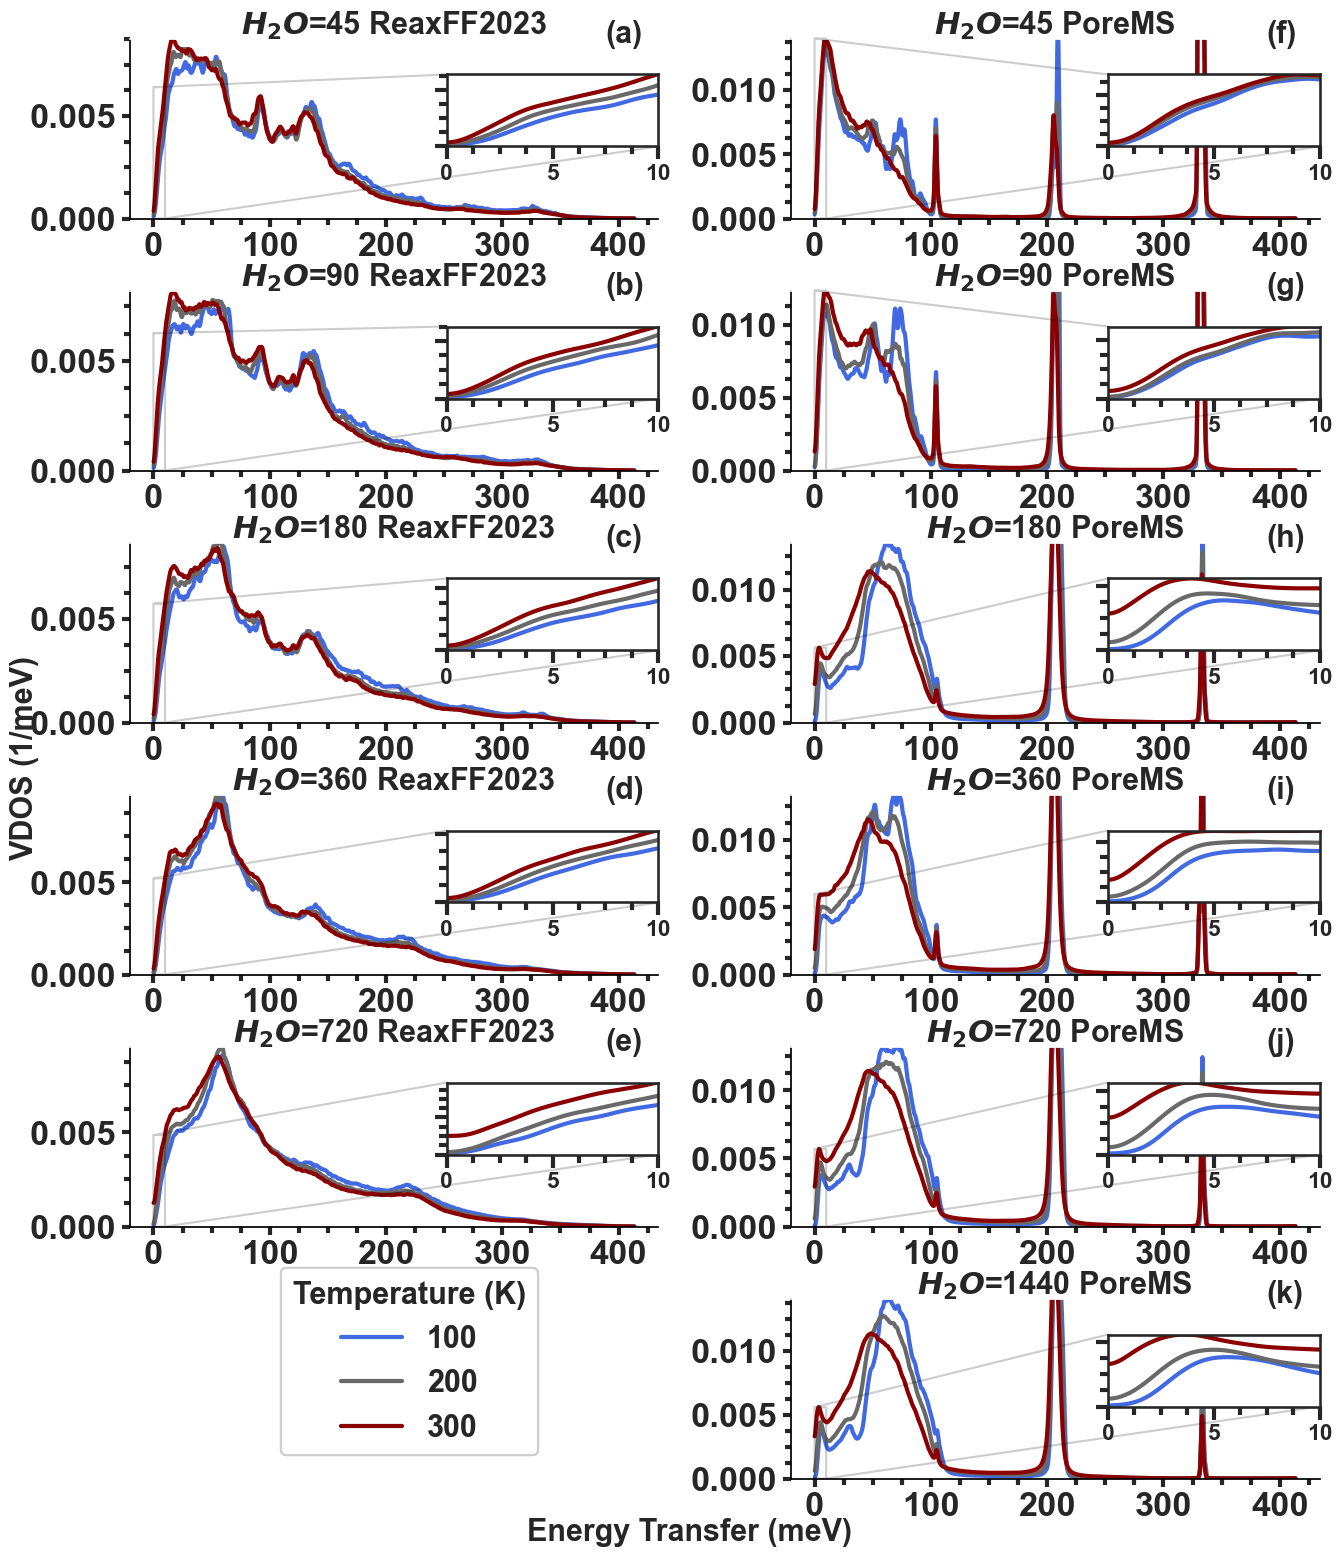

In [42]:
plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")

def apply_ax_format(ax,xlabel="",ylabel="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title


force_fields=df_dos_md["Force Field"].unique()
H2O_mol_list=df_dos_md["H2O Molecules"].unique()

fig, axs = plt.subplots(ncols=len(force_fields),nrows=len(H2O_mol_list),figsize=(7*len(force_fields),3*len(H2O_mol_list)))
sns.set_context("talk")
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
index=["(%s)"%x for x in list("abcdefghijkl")]

count=0
for j,force_field in enumerate(force_fields):
    for i, H2O_mol in enumerate(H2O_mol_list):
        ax=axs[i,j]
        
        df_tmp=df_dos_md.query("Weight== 'Incoherent' and `Force Field` == '%s' and `H2O Molecules` == %d and `Normalized Count` > 0"%(force_field,H2O_mol))
        if df_tmp.empty:
            ax.axis('off')
            ax.axis('tight')
            continue 
        ax.text(labx, laby, index[count],weight='bold' ,transform=ax.transAxes,fontsize=22)
        count+=1

        sns.lineplot(data=df_tmp
                    ,y="Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,ax=ax
                    ,palette=["royalblue","dimgrey","darkred"]
                    ,hue="Temperature (K)"
#                   ,color=palette[j]
                    ,legend=i*j==0
                     ,linewidth=3
               )

        ymax=df_tmp.query("`Energy Transfer (meV)` < 100")["Normalized Count"].max()
        ax.set_ylim(0,ymax)

        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(which='both',direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.set_ylabel("Normalized VDOS (1/meV)")

        
        ax.set_title("$H_2O$=%d %s"%(H2O_mol,force_field),y=0.975,fontsize=22)


        ax.set_xlabel("")
        ax.set_ylabel("")
                        
        if i*j ==0:
            sns.move_legend(ax,'center',bbox_to_anchor=(0.3,0.165),ncol=1,bbox_transform=fig.transFigure,fontsize=22,title_fontsize=22)

        ax.minorticks_on()
        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        
        
        x1, x2, y1, y2 = 0, 10, 0, df_tmp.query("`Energy Transfer (meV)` < 10")["Normalized Count"].max()
    
        xw=0.4
        axins = ax.inset_axes(
            [0.6, 0.4,0.4, 0.4]
            ,xlim=(x1, x2)
            , ylim=(y1, y2)
            #,xticklabels=[]
            , yticklabels=[]
            #, transform=ax.transData
        )
        
        sns.lineplot(data=df_tmp
                    ,y="Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,ax=axins
                    ,palette=["royalblue","dimgrey","darkred"]
                    ,hue="Temperature (K)"
#                   ,color=palette[j]
                    ,legend=False
                     ,linewidth=3
               )
        
        ax.indicate_inset_zoom(axins, edgecolor="black",alpha=0.2)
        apply_ax_format(axins,inset=True)

        
ax.text(0.5, 0.07, "Energy Transfer (meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22)         
ax.text(0.025, 0.5, "VDOS (1/meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22,rotation='vertical')         


            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.25, 
                    hspace=0.4
                   )

plt.savefig("../figures/fig7.pdf", pad_inches=0.2,bbox_inches="tight")